<a href="https://colab.research.google.com/github/sabbir2-dot/Django-Codes/blob/main/Air_Quality_Prediction_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Quality Prediction Using Machine Learning
This project focuses on predicting air pollutant levels using machine learning techniques. We use historical air quality data to train a model for pollutant prediction.
### Steps:
1. Load the dataset
2. Data cleaning and preprocessing
3. Exploratory Data Analysis (EDA)
4. Train a Random Forest Regressor
5. Evaluate the model
6. Save the trained model


In [ ]:
# Install necessary libraries
!pip install pandas scikit-learn matplotlib seaborn ucimlrepo

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from ucimlrepo import fetch_ucirepo

In [ ]:
# Load dataset (Air Quality Dataset from UCI Repository) using ucimlrepo
air_quality = fetch_ucirepo(id=360)
X = air_quality.data.features
y = air_quality.data.targets
data = pd.concat([X, y], axis=1) # Combine features and target into a single DataFrame

#Data Cleaning and preprocessing
data.columns = [col.strip().replace(' ', '_').replace('(', '').replace(')', '') for col in data.columns]  # Clean column names with spaces replaced by underscore
# data = data.rename(columns={'CO_GT': 'CO_GT'}) # Rename columns for consistency
data = data[data['COGT'] != -200]  # Filter invalid values, using the correct column name 'COGT'
# Select only numeric features for filling missing values
numeric_features = data.select_dtypes(include=np.number)
# Replace missing values with mean for numeric features only
data[numeric_features.columns] = numeric_features.fillna(numeric_features.mean())

print('Dataset loaded and preprocessed successfully!')
data.head()

Dataset loaded and preprocessed successfully!


,Date,Time,COGT,PT08.S1CO,NMHCGT,C6H6GT,PT08.S2NMHC,NOxGT,PT08.S3NOx,NO2GT,PT08.S4NO2,PT08.S5O3,T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [ ]:
# Data Cleaning
data = data.rename(columns={'CO(GT)': 'CO_GT'})
data = data[data['COGT'] != -200]  # Filter invalid values
# Select only numeric features for filling missing values
numeric_features = data.select_dtypes(include=np.number)
# Replace missing values with mean for numeric features only
data[numeric_features.columns] = numeric_features.fillna(numeric_features.mean())
print('Data cleaned successfully!')

Data cleaned successfully!


In [ ]:
print(data.columns)

Index(['Date', 'Time', 'COGT', 'PT08.S1CO', 'NMHCGT', 'C6H6GT', 'PT08.S2NMHC',
       'NOxGT', 'PT08.S3NOx', 'NO2GT', 'PT08.S4NO2', 'PT08.S5O3', 'T', 'RH',
       'AH'],
      dtype='object')


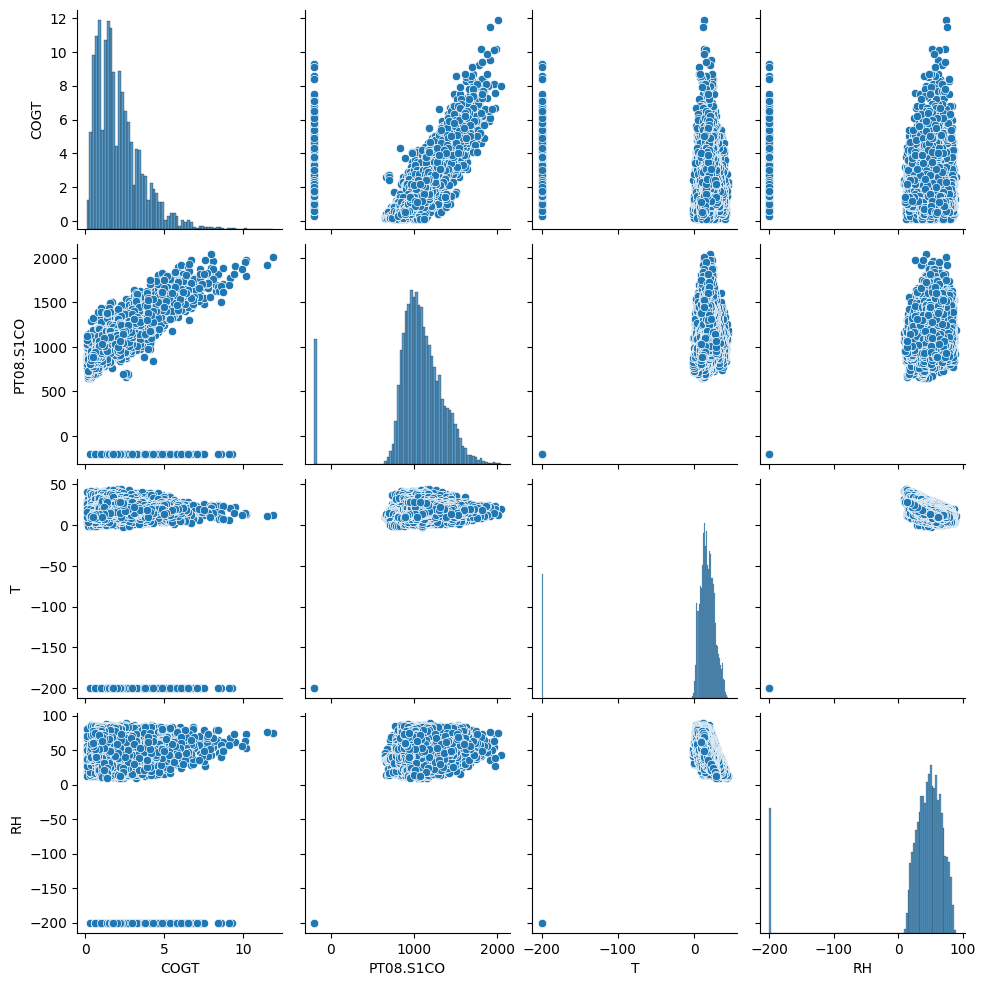

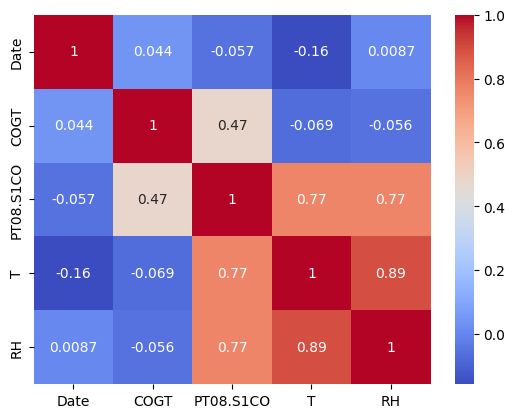

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
sns.pairplot(data[['Date', 'COGT', 'PT08.S1CO', 'T', 'RH']])
plt.show()
# Select columns for correlation
corr_data = data[['Date', 'COGT', 'PT08.S1CO', 'T', 'RH']]

# Calculate correlation and plot heatmap
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Feature and Target Selection
X = data[['PT08.S1CO', 'T', 'RH']]  # Features
y = data['COGT']  # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Data split into training and testing sets.')

Data split into training and testing sets.


In [ ]:
# Train a Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


R2 Score: 0.7568535460707206
Mean Squared Error: 0.506444259783735


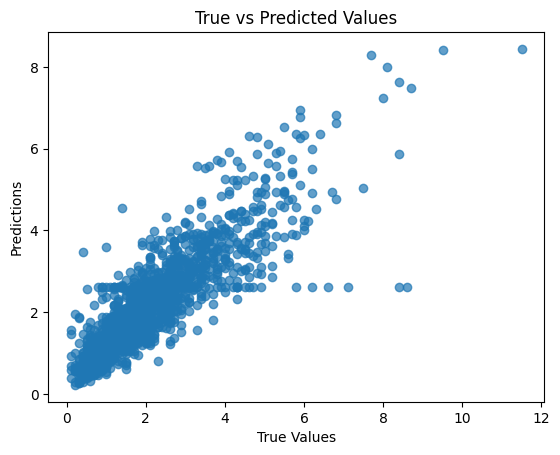

In [ ]:
# Model Evaluation
y_pred = model.predict(X_test)
print('R2 Score:', r2_score(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.show()

In [ ]:
# Save the model for deployment
joblib.dump(model, 'air_quality_model.pkl')
print('Model saved as air_quality_model.pkl')

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Define preprocessing pipeline
numeric_features = ['PT08.S1CO', 'T', 'RH']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Fill missing values with mean
    ('scaler', StandardScaler())                 # Scale features
])

# Combine preprocessors into a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

# Create a pipeline that combines preprocessing and the model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing step
    ('regressor', RandomForestRegressor(random_state=42))  # Model step
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the pipeline
pipeline.fit(X_train, y_train)
print('Pipeline trained successfully!')

# Evaluate the pipeline
y_pred = pipeline.predict(X_test)
print('R2 Score:', r2_score(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))

# Save the pipeline
joblib.dump(pipeline, 'air_quality_pipeline.pkl')
print('Pipeline saved as air_quality_pipeline.pkl')
